# Roman minimal pipeline v1 (crossmatch + cutout on AWS)

[解説記事](https://zenn.dev/rshimakawa/articles/roman-aws-analysis-env-setup)  
Roman 宇宙望遠鏡の公開シミュレーションデータ（STScI SOC simulations）に対して、
**カタログクロスマッチ → 画像切り出し → S3 保存** を最小構成で通す検証ノートブックです。

## 動作条件

- リージョン **us-east-1** の EC2（検証時は m7i-flex.large / 8 GB RAM）。
  S3 への書き込み権限を持つ IAM ロールをインスタンスに付与しておくこと
- パッケージ: `numpy pandas s3fs pyarrow astropy asdf matplotlib`
  (Roman ASDF を扱うなら `roman_datamodels`、スケール時は `lsdb` も)
- 冒頭の `MY_BUCKET` をご自身のバケット名に変更してください
- 入力データは公開バケット（匿名アクセス）なので認証不要で読めます（実データも予定通りなら同様）

## データクレジット

入力データは STScI が公開する Roman SOC simulated products (roman-2026.2, tutorial data) です（[詳細](https://roman-docs.stsci.edu/data-handbook/roman-research-nexus)）。


# Roman 最小パイプライン v1
**目的**: 公開 S3 上の Roman シミュレーション検出カタログに対して、
1. 外部カタログとのクロスマッチ
2. マッチ天体の画像切り出し
3. 自前 S3 への保存

という本番想定の一連の流れを最小構成で通す。

外部カタログは、検出カタログ自体に決定論的な位置ずれ（Rayleigh σ=0.1"）を与えた疑似カタログを使う（正解が既知なので再現率が厳密に測れる）。

In [ ]:
# --- 設定 ---
MY_BUCKET = "YOUR-BUCKET-roman-work"   # 自分のバケット名に変更
ROMAN_PREFIX = "stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2"
MATCH_RADIUS_ARCSEC = 1.0
SIGMA_ARCSEC = 0.1        # 疑似カタログの位置ずれ
N_CUTOUT = 9              # 切り出す天体数
CUTOUT_SIZE = 50          # ピクセル

In [ ]:
import numpy as np, pandas as pd, s3fs, pyarrow.parquet as pq
import matplotlib.pyplot as plt

fs_pub  = s3fs.S3FileSystem(anon=True)   # 公開データ（匿名）
fs_mine = s3fs.S3FileSystem()            # 自分のバケット（EC2 のロール権限）

cat_paths = sorted(fs_pub.glob(f"{ROMAN_PREFIX}/**/*_cat.parquet"))
print(len(cat_paths), "catalogs")
for p in cat_paths[:5]:
    print(" ", p)

73 catalogs
  stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/my_roman_mosaic_cat.parquet
  stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi01_f106_cat.parquet
  stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi02_f106_cat.parquet
  stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi03_f106_cat.parquet
  stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi04_f106_cat.parquet


In [4]:
# --- 1. 検出カタログを 1 本読む ---
CAT = cat_paths[0]
tbl = pq.read_table("s3://" + CAT, filesystem=fs_pub)
cat = tbl.to_pandas()
print(CAT.split("/")[-1], "->", len(cat), "rows")

# ra/dec 列名の確認
radec = [c for c in cat.columns if c.lower() in ("ra","dec")]
print("coord columns:", radec)
RA, DEC = radec[0], radec[1]
cat[[RA, DEC]].describe()

my_roman_mosaic_cat.parquet -> 4532 rows
coord columns: ['ra', 'dec']


,ra,dec
count,4532.000000,4532.000000
mean,270.967187,-0.315937
std,0.048619,0.048830
min,270.869324,-0.419008
25%,270.931342,-0.354191
50%,270.964761,-0.310294
75%,271.003109,-0.280538
max,271.069952,-0.222452


In [ ]:
# --- 2. 疑似「外部カタログ」を作る（決定論的 Rayleigh オフセット）---
rng = np.random.default_rng(20260825)     # シード固定 = 再現可能
n = len(cat)
r_off  = SIGMA_ARCSEC/3600.0 * np.sqrt(-2*np.log(rng.uniform(1e-12, 1, n)))
theta  = rng.uniform(0, 2*np.pi, n)
ext = pd.DataFrame({
    "ext_id": cat.index.values,           # 正解ラベル(=元の行番号)
    "ra":  cat[RA].values  + r_off*np.sin(theta)/np.cos(np.radians(cat[DEC].values)),
    "dec": cat[DEC].values + r_off*np.cos(theta),
})
print(len(ext), "external sources / median offset =",
      np.median(r_off)*3600, "arcsec")

4532 external sources / median offset = 0.1170878303902916 arcsec


In [ ]:
# --- 3. クロスマッチ検証 ---
from astropy.coordinates import SkyCoord
import astropy.units as u

c_cat = SkyCoord(cat[RA].values*u.deg,  cat[DEC].values*u.deg)
c_ext = SkyCoord(ext["ra"].values*u.deg, ext["dec"].values*u.deg)

idx, sep, _ = c_ext.match_to_catalog_sky(c_cat)
ok = sep < MATCH_RADIUS_ARCSEC * u.arcsec

matched = cat.iloc[idx[ok]].copy().reset_index(names="cat_index")
matched["ext_id"]     = ext["ext_id"].values[ok]
matched["sep_arcsec"] = sep[ok].arcsec

recovery = ok.sum() / len(ext)
correct  = (matched["cat_index"] == matched["ext_id"]).mean()
print(f"matched {ok.sum()}/{len(ext)}  (recovery {recovery:.4%})")
print(f"correct identification {correct:.4%}")
matched[["cat_index","ext_id","sep_arcsec",RA,DEC]].head()

matched 4532/4532  (recovery 100.0000%)
correct identification 100.0000%


,cat_index,ext_id,sep_arcsec,ra,dec
0,0,0,0.075436,270.970980,-0.418790
1,1,1,0.117804,270.973237,-0.419008
2,2,2,0.130047,270.995729,-0.418941
3,3,3,0.126476,270.964511,-0.418814
4,4,4,0.257206,270.936834,-0.418498


> **メモ**: 10⁷ 行級を超えると上の総当たり一括読みが厳しくなるので、
> `lsdb`(HATS 分割 + Dask)に置き換える。<br>API は
> `lsdb.from_dataframe(df, ra_column=..., dec_column=...)` → `left.crossmatch(right, radius_arcsec=1)`。

In [7]:
# --- 4. マッチ天体の画像切り出し ---
# カタログと同じ接頭辞の L3 coadd (ASDF) を探す
stem = CAT.rsplit("_cat.parquet", 1)[0]
coadds = fs_pub.glob(stem + "*coadd*.asdf") or fs_pub.glob("/".join(CAT.split("/")[:-1]) + "/*coadd*.asdf")
print("coadd candidates:", coadds[:3])
COADD = "s3://" + coadds[0]

targets = matched.nsmallest(N_CUTOUT, "sep_arcsec")   # とりあえず上位 N 個
coords  = SkyCoord(targets[RA].values*u.deg, targets[DEC].values*u.deg)

coadd candidates: ['stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/my_roman_mosaic_coadd.asdf']


In [ ]:
%%time
# astrocut（Roman ASDF + S3 URI 対応）
import asdf

# 画像と WCS を 1 回だけ読む（~180 MB、メモリ 8 GB に余裕で収まる）
with fs_pub.open(coadds[0], "rb") as f, asdf.open(f, lazy_load=True) as af:
    img = np.asarray(af["roman"]["data"])          # ここで一括ロード
    wcs = af["roman"]["meta"]["wcs"]

xs, ys = wcs.world_to_pixel(coords)
h = CUTOUT_SIZE // 2
cut_imgs = []
for x, y in zip(np.atleast_1d(xs), np.atleast_1d(ys)):
    xi, yi = int(round(float(x))), int(round(float(y)))
    cut_imgs.append(img[yi-h:yi+h, xi-h:xi+h].copy())

print(len(cut_imgs), "cutouts")
del img   # 使い終わったらメモリを返す

9 cutouts
CPU times: user 665 ms, sys: 287 ms, total: 952 ms
Wall time: 5.69 s


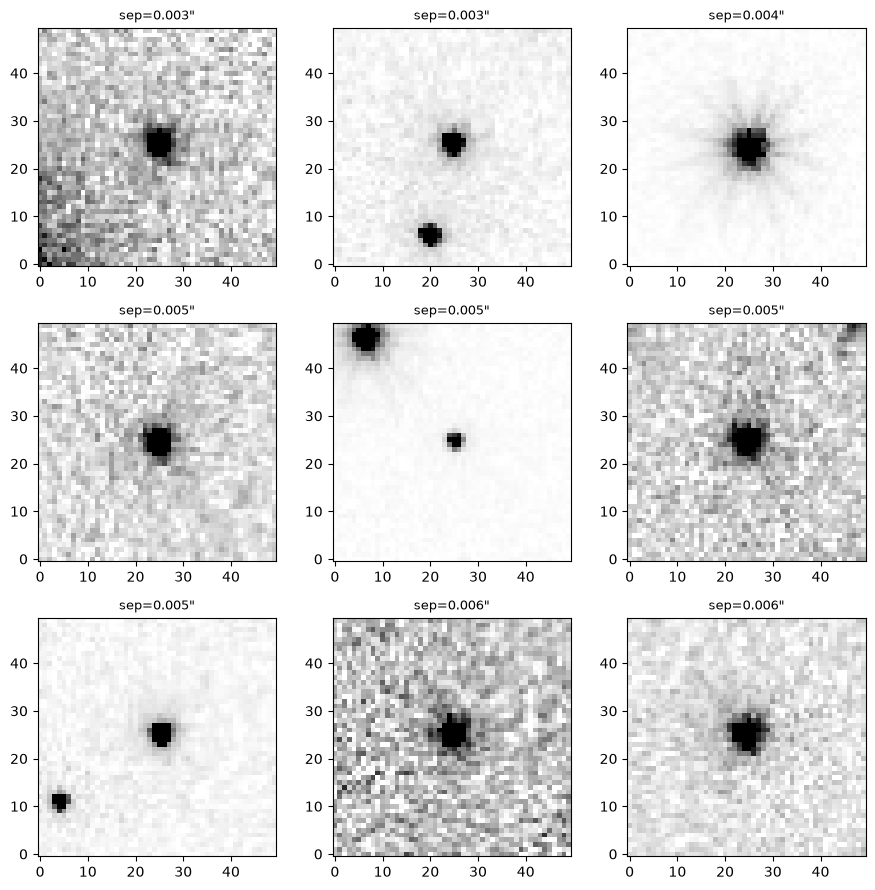

In [ ]:
# --- 5. カットアウト表示 ---
ncol = 3
nrow = int(np.ceil(len(cut_imgs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3*nrow))
for ax, img, (_, t) in zip(np.ravel(axes), cut_imgs, targets.iterrows()):
    v = np.nanpercentile(img, [5, 99])
    ax.imshow(img, vmin=v[0], vmax=v[1], origin="lower", cmap="gray_r")
    ax.set_title(f"sep={t.sep_arcsec:.3f}\"", fontsize=9)
for ax in np.ravel(axes)[len(cut_imgs):]:
    ax.axis("off")
plt.tight_layout()

In [ ]:
# --- 6. アウトプットを自前 S3 バケットに保存 ---
import io, pyarrow as pa

out_prefix = f"{MY_BUCKET}/pipeline_v1"

# マッチ済みカタログ (Parquet)
buf = io.BytesIO()
matched.to_parquet(buf, index=False)
with fs_mine.open(f"{out_prefix}/matched_catalog.parquet", "wb") as f:
    f.write(buf.getvalue())

# 切り出し画像 (npz)
buf = io.BytesIO()
np.savez_compressed(buf, *cut_imgs)
with fs_mine.open(f"{out_prefix}/cutouts.npz", "wb") as f:
    f.write(buf.getvalue())

print(fs_mine.ls(out_prefix))

['YOUR-BUCKET-roman-work/pipeline_v1/cutouts.npz', 'YOUR-BUCKET-roman-work/pipeline_v1/matched_catalog.parquet']
